# AI Project 
## Endeavour

### Import python packages
We had alot of issues doing these imports.
<p>At first our virtual environments weren't working because we tried to share them to eachother for liveshare. The python versions were different on each machine so the environments were attempting to run with the wrong versions on different machines.</p>

<p>There were other unexplained issues that stopped us from being able to install new packages. This was fixed by recreating the virtual environment.</p>

<p>We setled on keeping our own virtual environments isolated and only sharing the notebook files.</p>

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

import joblib
import sklearn.impute 

## Clean the Dataset
<p>Only cleaning required is the removal of the "incompletable" rows. These indicate tests that cannot be applied to the vehicle. But most of these are just 0's and not useful to us.</p>
<p>The reduced dataset is written to a new .csv file.</p>

In [71]:
file = open("MakeModelData2016.csv", "r")
new_file = open("newData.csv", "a")
for line in file:

    index = line.rfind(",")
    line = line[: index]

    index = line.rfind(",")
    line = line[: index]

    new_file.write(line + "\n")
new_file.close()
file.close()

## Transfer dataset into a Panda's dataframe
<p>This will be the root dataframe that all other dataframes will stem from.</p>
<p>Dataframes make it easy to work on the data. It functions like an excel sheet and whole columns can be referenced directly.</p>

In [72]:
cars = pd.read_csv("newData.csv")

Displays the firsts few rows of the data frame.

In [73]:
cars.head()

,VehicleMake,VehicleModel,YearOfBirth,Total,PASS,PASS %,FAIL,FAIL %,Vehicle and Safety Equipment,Vehicle and Safety Equipment %,...,Suspension Test,Suspension Test %,Light test,Light test %,Brake Test,Brake Test %,Emmissions,Emmissions %,OTHER,OTHER %
0,ALFA ROMEO,145,1996,1,1,100.0,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1,ALFA ROMEO,145,1997,1,1,100.0,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
2,ALFA ROMEO,145,1998,4,2,50.0,2,50.0,1,25.0,...,0,0.0,0,0.0,1,25.0,0,0.0,0,0.0
3,ALFA ROMEO,145,1999,3,0,0.0,3,100.0,0,0.0,...,0,0.0,0,0.0,0,0.0,2,66.7,0,0.0
4,ALFA ROMEO,145,2000,2,1,50.0,1,50.0,0,0.0,...,0,0.0,0,0.0,1,50.0,0,0.0,0,0.0


## Remove rare makes
<p>Having one off makes is useless for making predictions on as there are too few samples of the make to build any understanding of them. Having one offs also prevents us from stratifying the training set later (evenly distributing rows based on vehicle make).</p>

<p>The code below removes makes that don't appear atleast five times within the dataset.</p>

In [74]:
# get number of different vahicle makes within column and set it as a variable
make_counts = cars["VehicleMake"].value_counts()

# set valid columns to makes that appear atleast 5 times
valid_makes = make_counts[make_counts > 5].index

# update cars dataframe to vehicle makes that are in valid makes, reset index keeps index orders intact after dropping (if we don't drop there will be empty indexes within columns)
cars = cars[cars["VehicleMake"].isin(valid_makes)].reset_index(drop=True)

This lists the columns within the frame, the number of non-0 rows and their object types.

In [75]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8061 entries, 0 to 8060
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   VehicleMake                     8061 non-null   object 
 1   VehicleModel                    8061 non-null   object 
 2   YearOfBirth                     8061 non-null   int64  
 3   Total                           8061 non-null   int64  
 4   PASS                            8061 non-null   int64  
 5   PASS %                          8061 non-null   float64
 6   FAIL                            8061 non-null   int64  
 7   FAIL %                          8061 non-null   float64
 8   Vehicle and Safety Equipment    8061 non-null   int64  
 9   Vehicle and Safety Equipment %  8061 non-null   float64
 10  Lighting and Electrical         8061 non-null   int64  
 11  Lighting and Electrical %       8061 non-null   float64
 12  Steering and Suspension         80

Provides statistics for each column.

In [76]:
cars.describe()

,YearOfBirth,Total,PASS,PASS %,FAIL,FAIL %,Vehicle and Safety Equipment,Vehicle and Safety Equipment %,Lighting and Electrical,Lighting and Electrical %,...,Suspension Test,Suspension Test %,Light test,Light test %,Brake Test,Brake Test %,Emmissions,Emmissions %,OTHER,OTHER %
count,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,...,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000,8061.000000
mean,2002.373031,181.805359,87.174296,46.631410,94.631063,53.369284,18.928421,13.690262,36.552041,18.939772,...,9.794939,5.341136,12.673490,6.906798,21.749039,13.011649,9.929909,6.463478,0.819998,0.598722
std,8.377295,666.068719,329.538593,31.822753,363.659480,31.822851,71.147971,21.523713,151.034931,23.193177,...,41.304627,13.496521,54.692228,15.230302,99.569545,21.203652,45.180357,14.858165,3.284330,4.921091
min,1932.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1998.000000,2.000000,1.000000,25.000000,1.000000,31.300000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2004.000000,10.000000,4.000000,44.500000,5.000000,55.500000,1.000000,6.700000,2.000000,14.300000,...,0.000000,0.000000,1.000000,1.100000,1.000000,2.900000,0.000000,0.000000,0.000000,0.000000
75%,2008.000000,70.000000,32.000000,68.700000,34.000000,75.000000,7.000000,16.700000,12.000000,26.700000,...,3.000000,5.800000,4.000000,7.900000,6.000000,19.000000,3.000000,6.700000,0.000000,0.000000
max,2016.000000,12148.000000,6313.000000,100.000000,6681.000000,100.000000,1079.000000,100.000000,3628.000000,100.000000,...,866.000000,100.000000,1282.000000,100.000000,2089.000000,100.000000,865.000000,100.000000,52.000000,100.000000


## Confusion matrix
<p>Used by each algorithm to display a visual of right and wrong predictions.</p>

In [77]:
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(3.5,3.5))
    ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    plt.show()

## Separating dependant and independant variables
<p>The first step is to eliminate clutter. The percentage and totals columns are not needed because they're derived from other columns.</p>
<p>All that's needed for the features is all of the test types which contain a number of failures for the test. The last two features are make and year.</p>
<p>Vehicle make needs to be one-hot encoded so it's a boolean of true for whichever make it actually is. This is because features can't be strings within a training set.</p>
<p>The variable that will be predicted is main failure. This is a new column added onto the cars dataframe. It contains the name of the failure column with the highest value.</p>
<p>Note; we're unsure how useful this prediction is because it can be derived quite easily. But the models are doing work and providing different accuracies. This should still be useful for new cars, and the algorithms still have to make their own prediction for rows with no failures (which is likely the reason accuracy isn't 100%)</p>

In [78]:
# columns that will be used for the prediction
failures = ["Vehicle and Safety Equipment", "Lighting and Electrical", "Steering and Suspension", 
                 "Braking Equipment", "Wheels and Tyres", "Engine, Noise and Exhaust", "Chassis and Body", 
                 "Side Slip Test", "Suspension Test", "Light test", "Brake Test", "Emmissions", "OTHER"]

# we will predict main failure based on make and all its failures (independant variables)
X = cars[["VehicleMake", "YearOfBirth"] + failures]

# use one-hot (meaning one is true) encoding to encode strings into booleans, this means it will take every possible make and encode is as a binary value for whichever one is true
# only needs to be done for X columns
X = pd.get_dummies(X, columns = ["VehicleMake"]) 
print(X)

# find which feature column has the highest value and make a new column containing the column name 
cars["Main Failure"] = cars[failures].idxmax(axis=1)

# column to predict (dependant variable)
y = cars["Main Failure"]
print(y)


      YearOfBirth  Vehicle and Safety Equipment  Lighting and Electrical  \
0            1996                             0                        0   
1            1997                             0                        0   
2            1998                             1                        2   
3            1999                             0                        0   
4            2000                             0                        1   
...           ...                           ...                      ...   
8056         2010                             0                        4   
8057         2011                             1                        2   
8058         2012                             2                        1   
8059         2013                             0                        0   
8060         2005                             0                        0   

      Steering and Suspension  Braking Equipment  Wheels and Tyres  \
0                

## Split into training sets
<p>Here we take a slice of the data with a fixed random seed for use in training the models.</p>

<p>The data is stratified to include an even distribution of makes within the training sets. Be sure to stratify by y_temp for the validation set (doing so by y again will use the y of the entire set rather than the existing split's share)</p>

<p>Doing this made each model score slightly higher accuracy.</p>

In [79]:
# split into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp)


## Linear regression

Validation Accuracy: 0.9025686448184234 
Test Accuracy: 0.9090909090909091


/home/user_d/Desktop/project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


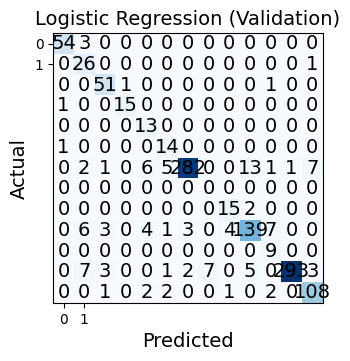

In [80]:
# linear regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced") # define and set max iterations 
log_reg.fit(X_train, y_train) # fit to training data

y_val_lr = log_reg.predict(X_val) # predict x values
y_test_lr = log_reg.predict(X_test) # predict x test values

val_acc_lr = accuracy_score(y_val, y_val_lr) # accuracy of predicted y vs actual y
test_acc_lr = accuracy_score(y_test, y_test_lr) # accuracy of predicted test y values vs actual test y values
cm_lr = confusion_matrix(y_val, y_val_lr) 

print("Validation Accuracy:", val_acc_lr, "\nTest Accuracy:", test_acc_lr)
labels = log_reg.classes_
plot_confusion_matrix(cm_lr, "Logistic Regression (Validation)")

## Nearest neighbors

Validation Accuracy: 0.75022143489814 
Test Accuracy: 0.7355371900826446


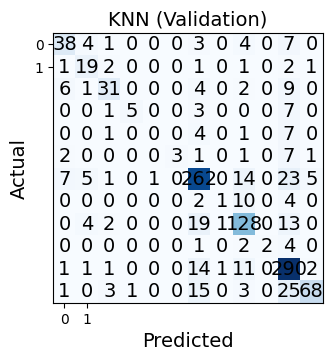

In [81]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_val_knn = knn.predict(X_val)
y_test_knn = knn.predict(X_test)
val_acc_knn = accuracy_score(y_val, y_val_knn)
test_acc_knn = accuracy_score(y_test, y_test_knn)
cm_knn = confusion_matrix(y_val, y_val_knn)
print("Validation Accuracy:", val_acc_knn, "\nTest Accuracy:", test_acc_knn)
plot_confusion_matrix(cm_knn, "KNN (Validation)")

## Naive bayes
<p>Worst accuracy by far. We will elaborate on why this might be.</p>

Validation Accuracy: 0.05757307351638618 
Test Accuracy: 0.07231404958677685


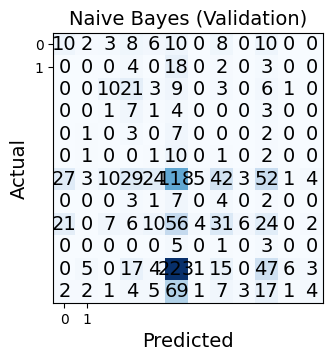

In [82]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_val_nb = nb.predict(X_val)
y_test_nb = nb.predict(X_test)
val_acc_nb = accuracy_score(y_val, y_val_nb)
test_acc_nb = accuracy_score(y_test, y_test_nb)
cm_nb = confusion_matrix(y_val, y_val_nb)
print("Validation Accuracy:", val_acc_nb, "\nTest Accuracy:", test_acc_nb)
plot_confusion_matrix(cm_nb, "Naive Bayes (Validation)")

## Random forest

Validation Accuracy: 0.8299379982285208 
Test Accuracy: 0.8057851239669421


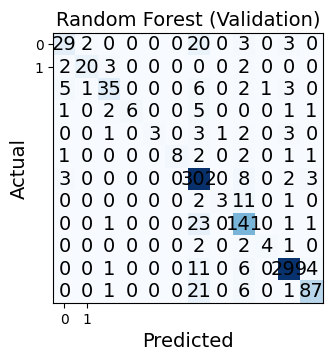

In [83]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_val_rf = rf.predict(X_val)
y_test_rf = rf.predict(X_test)
val_acc_rf = accuracy_score(y_val, y_val_rf)
test_acc_rf = accuracy_score(y_test, y_test_rf)
cm_rf = confusion_matrix(y_val, y_val_rf)
print("Validation Accuracy:", val_acc_rf, "\nTest Accuracy:", test_acc_rf)
plot_confusion_matrix(cm_rf, "Random Forest (Validation)")

## Gradient boosting

Validation Accuracy: 0.8981399468556245 
Test Accuracy: 0.9008264462809917


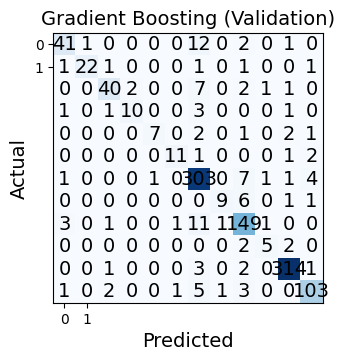

In [84]:
gbt = GradientBoostingClassifier(random_state=42)
gbt.fit(X_train, y_train)
y_val_gbt = gbt.predict(X_val)
y_test_gbt = gbt.predict(X_test)
val_acc_gbt = accuracy_score(y_val, y_val_gbt)
test_acc_gbt = accuracy_score(y_test, y_test_gbt)
cm_gbt = confusion_matrix(y_val, y_val_gbt)
print("Validation Accuracy:", val_acc_gbt, "\nTest Accuracy:", test_acc_gbt)
plot_confusion_matrix(cm_gbt, "Gradient Boosting (Validation)")

## Accuracy comparisons
<p>This is just for comparing the accuracy of each model in a neat bar chart.</p>

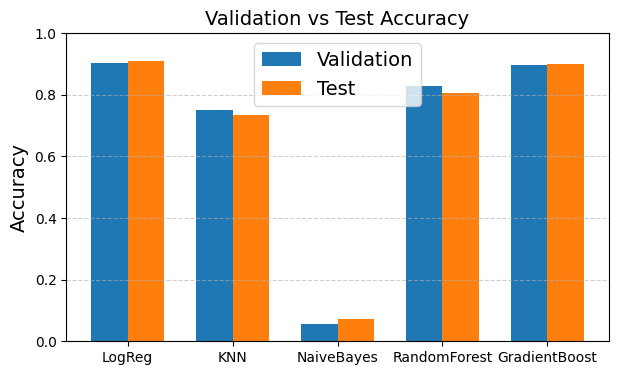

In [85]:
models = ["LogReg", "KNN", "NaiveBayes", "RandomForest", "GradientBoost"]
val_accs = [val_acc_lr, val_acc_knn, val_acc_nb, val_acc_rf, val_acc_gbt]
test_accs = [test_acc_lr, test_acc_knn, test_acc_nb, test_acc_rf, test_acc_gbt]

x = np.arange(len(models))
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(x - width/2, val_accs, width, label="Validation")
plt.bar(x + width/2, test_accs, width, label="Test")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Validation vs Test Accuracy")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


## Results
<p>The accuracy of most models is very good when predicting the main failure of each car. But it was already explained above as to why that might not be much of an achievement. We think machine larning is not the right approach for a dataset like this. By default there is alot of clutter and most of the tests have 0 failures.</p>

<p>This result is better achieved using a traditional statistics approach.</p>

## Graphs
<p>This is a function that can plot a single column when fed its name as an argument. Should only be used for deeper analysis as each graph takes up alot of the notebook.</p>


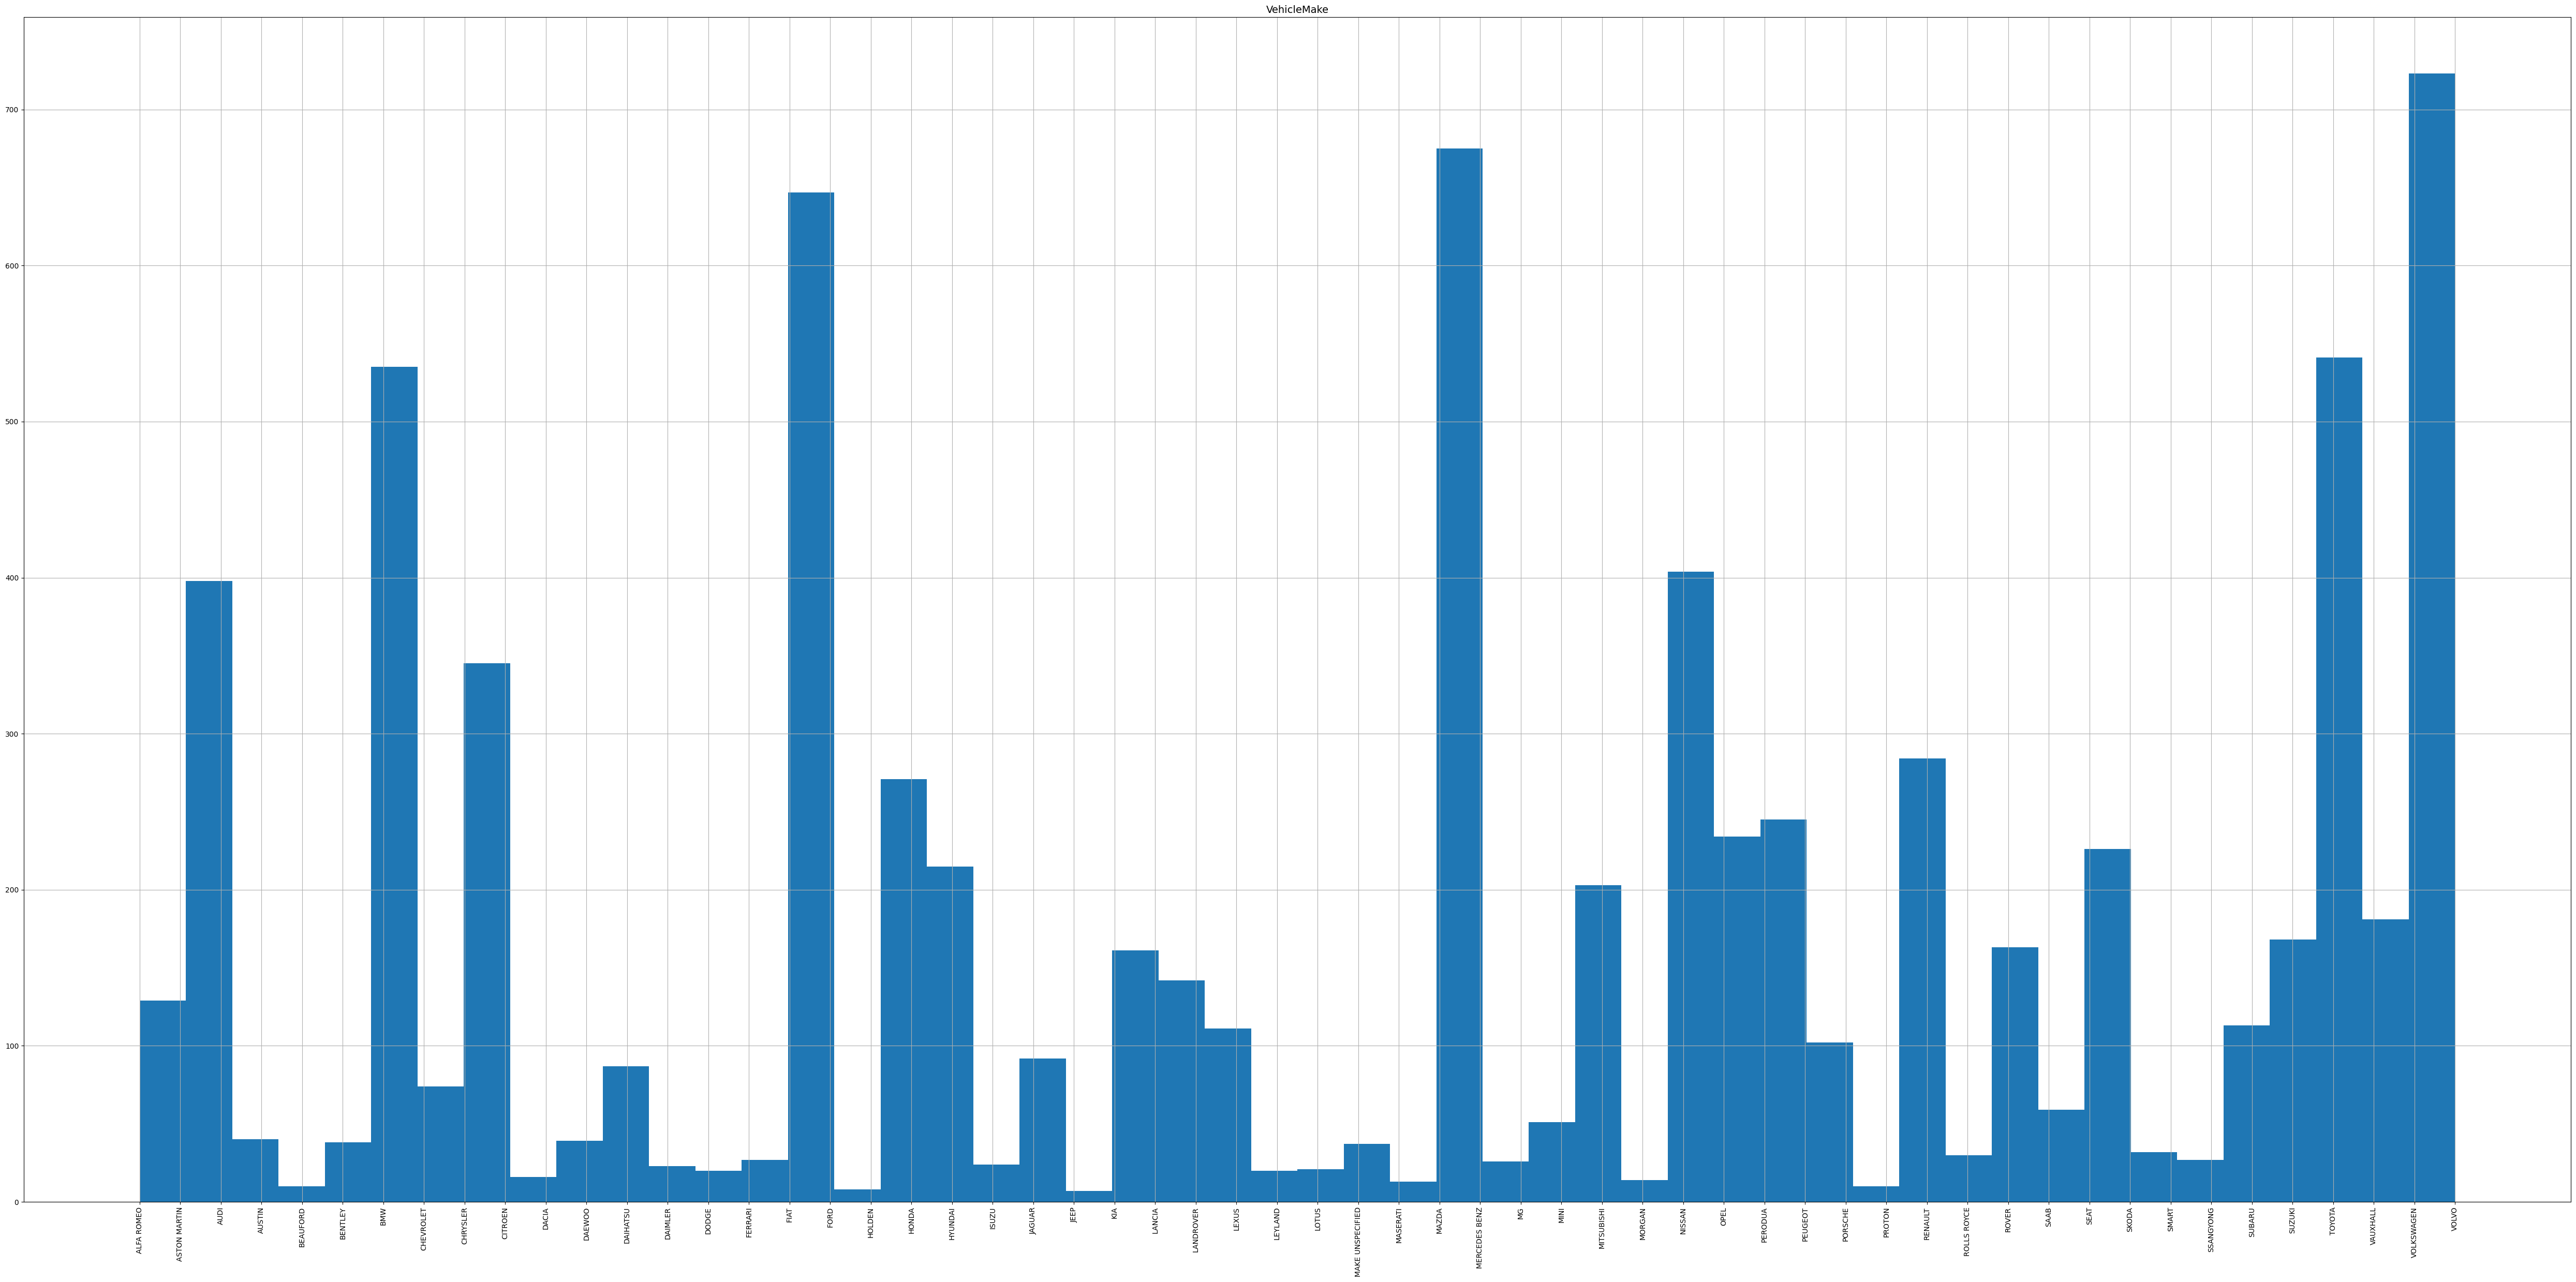

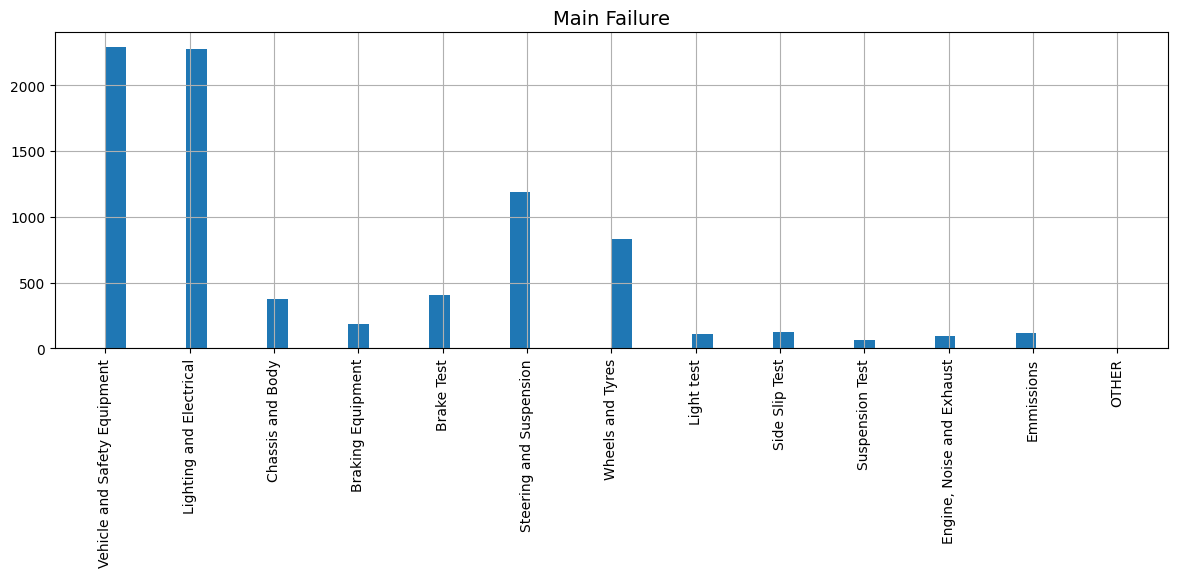

In [86]:
# function to plot graph 
def graph(frameName, s1, s2):
    plt.plot(kind="bar")
    plt.rc("font", size=14)
    plt.rc("axes", labelsize=14, titlesize=14)
    plt.rc("legend", fontsize=14)
    plt.rc("xtick", labelsize=10)
    plt.rc("ytick", labelsize=10)
    plt.title(frameName)
    plt.xticks(rotation=90, ha="center") # rotate x labels vetically

    cars[frameName].hist(bins=50, figsize=(s1, s2)) # scale based on arguments
    plt.tight_layout()
    plt.show()

# loop to graph all columns
#for header in (cars):
    #graph(header, 50, 25)

graph("VehicleMake", 50, 25)
#graph("VehicleModel", 50, 25) pointless to graph as alot of models are just "OTHER" and there's far too many of them
graph("Main Failure", 12, 6)

## Main failures for a make
<p>This code will group main failures of all cars within a make to its make. From this we can graph the most common failures that show up on any given make. Sometimes there will be less X features within a graph if the sample size of a make is small enough to have no main failures for a specific category.</p>

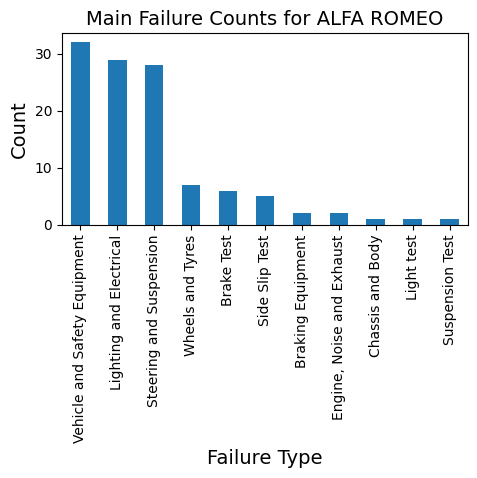

In [87]:
# use pandas group by function to group vehicle makes and their main failures together
# value counts will count the total main failures from all cars within a make
grouped = cars.groupby("VehicleMake")["Main Failure"].value_counts()

# set makes to be all unique makes from main dataframe
makes = cars["VehicleMake"].unique()

# set a specific make to plot as an example, to not clutter the notebook with each graph
make_to_plot = "ALFA ROMEO"

# set main failures to be the counts from the group for the specific make
mainFails = grouped[make_to_plot]

# create a plot
plt.figure(figsize=(5, 5))

mainFails.plot(kind="bar")
plt.title(f"Main Failure Counts for {make_to_plot}")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.xticks()
plt.tight_layout()
plt.show()

## Unified graphs
<p>Graphs everything within one page. We had to adjust bin and figure size to get everything to fit neatly.</p>

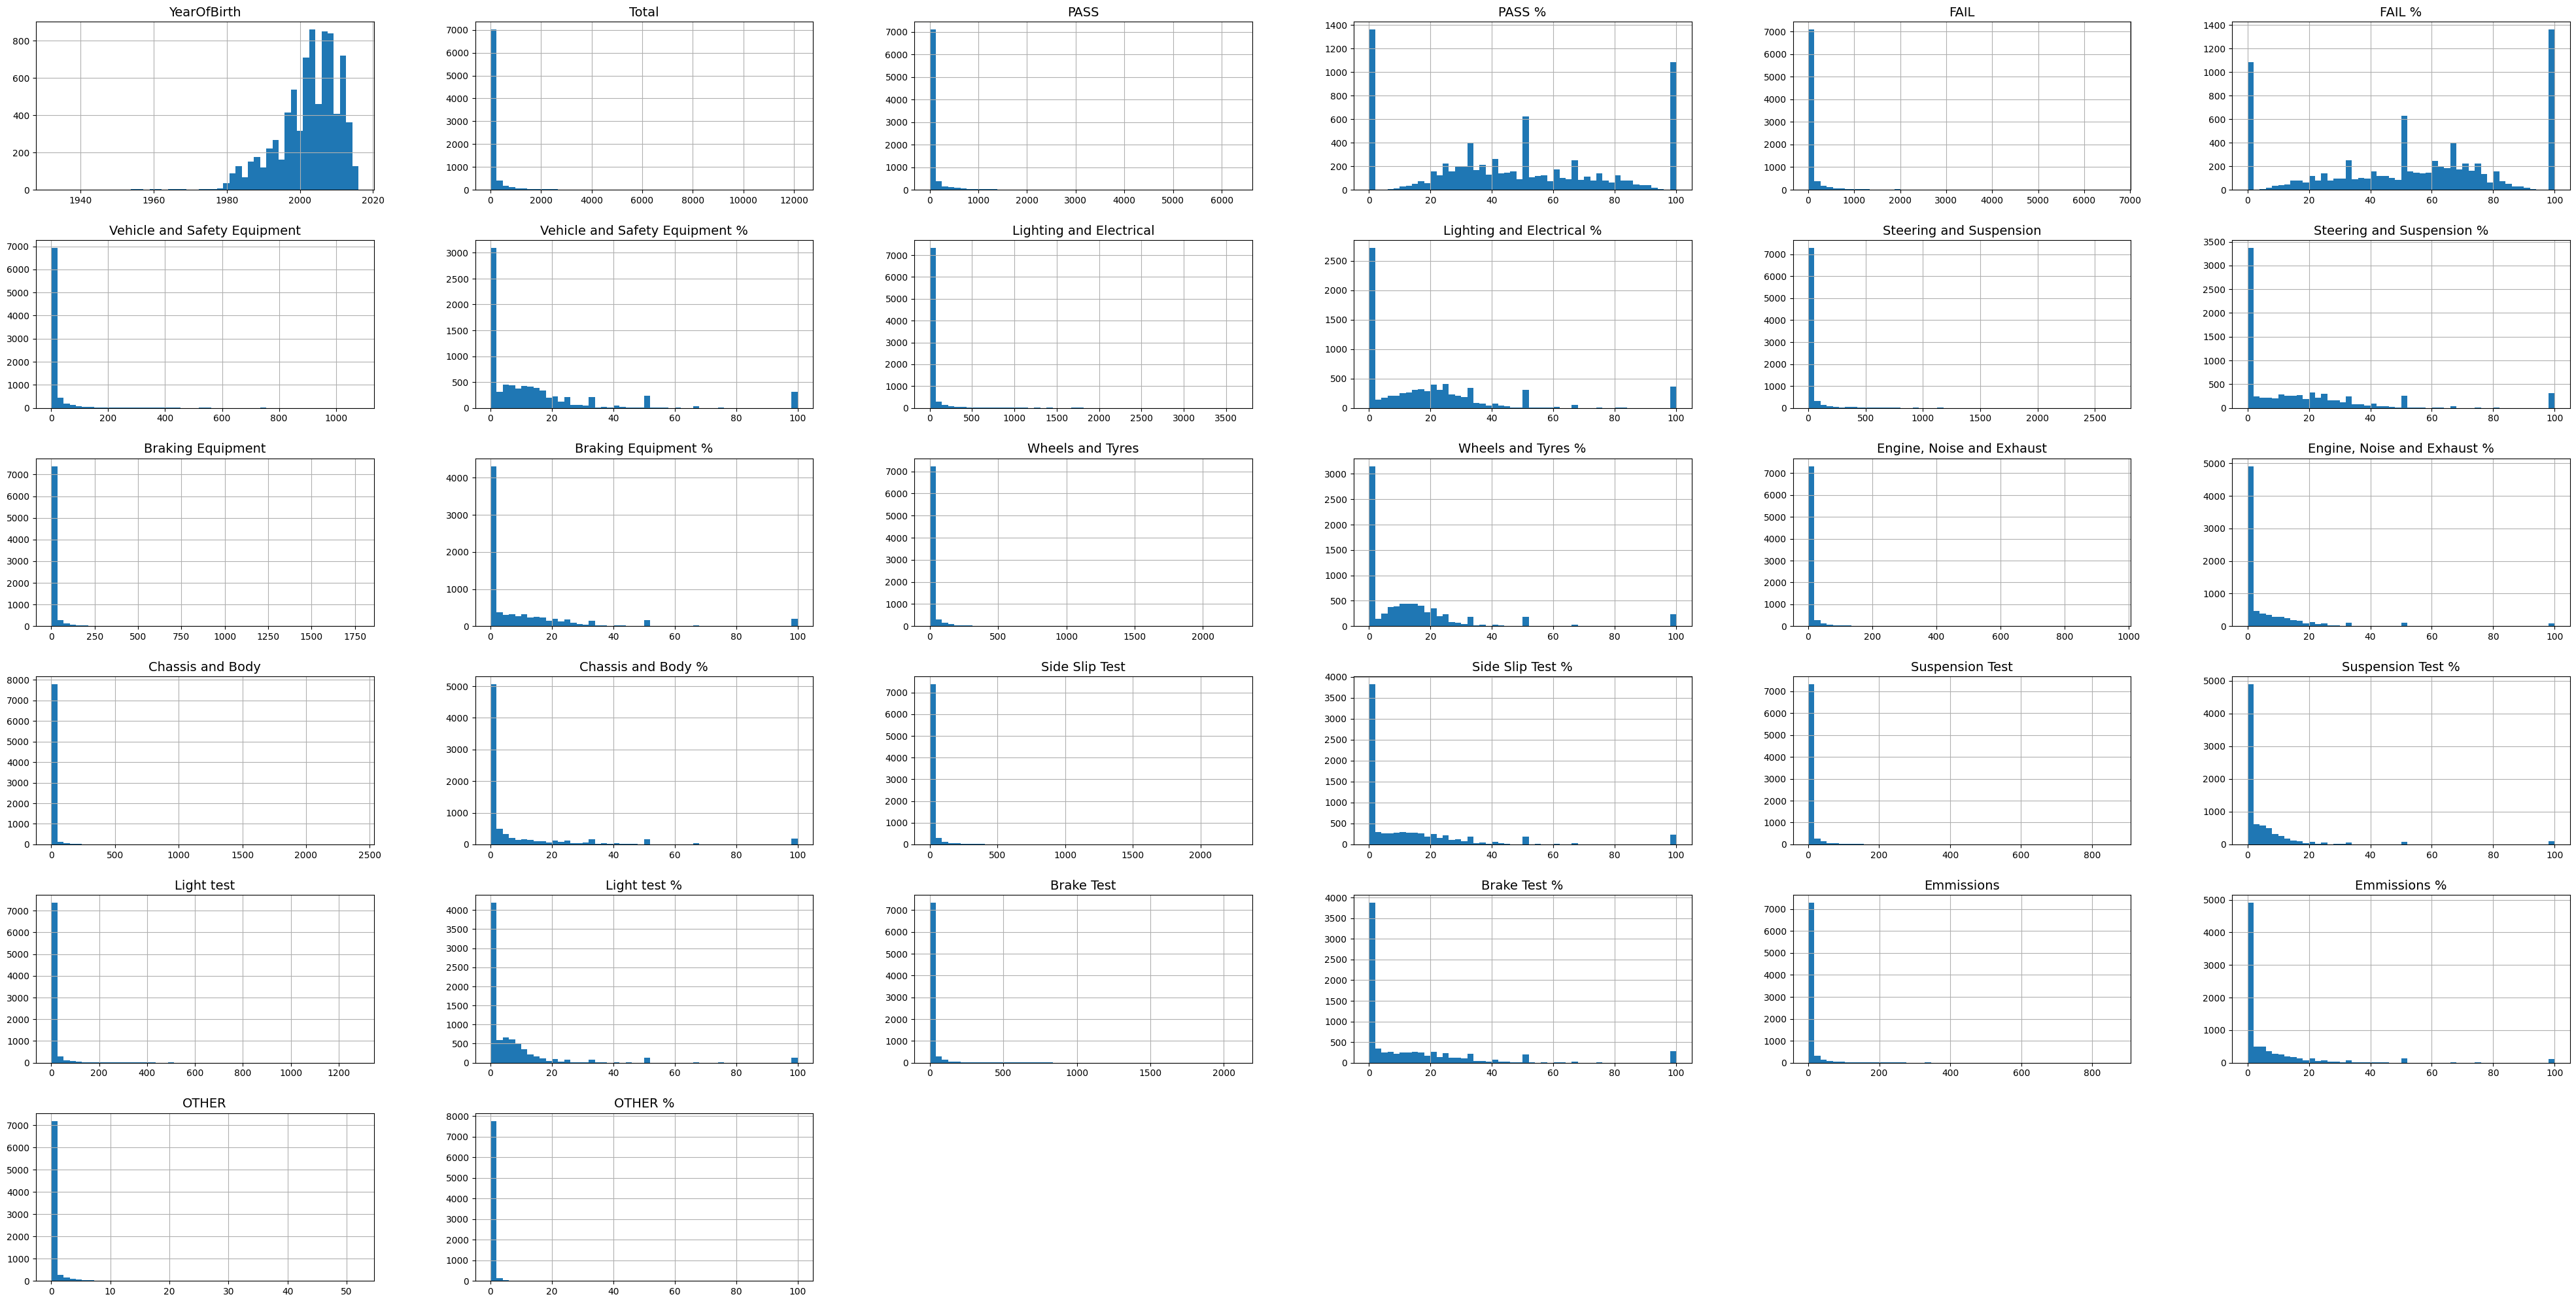

In [88]:
# graph everything in one page
plt.rc("font", size=12)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

cars.hist(bins=50, figsize=(50, 25)) # play around with these values to get the right size
plt.show()

## Enter new rows to predict
<p>Formatting of the new row needs to be strictly in line with a row within the main dataset. Reindexing has to be performed on the new X data to clean up any missing indexes after using one-hot encoding.</p>

In [ ]:
# define failure amounts in the same format as originally
failures = {
    "Vehicle and Safety Equipment": 0,
    "Lighting and Electrical": 0,
    "Steering and Suspension": 0,
    "Braking Equipment": 1,
    "Wheels and Tyres": 0,
    "Engine, Noise and Exhaust": 0,
    "Chassis and Body": 0,
    "Side Slip Test": 0,
    "Suspension Test": 0,
    "Light test": 0,
    "Brake Test": 0,
    "Emmissions": 0,
    "OTHER": 0
}

# .get is required to compare the values themselves rather than just the dictionary keys
main_failure = max(failures, key=failures.get)

# setup a dictionary where column name = set value
new_row = {"VehicleMake": "ALFA ROMEO", "YearOfBirth": 2005}

# add failures by merging both dictionaries
new_row.update(failures)  

# convert to dataframe, make sure to treat dictionary as a list
new_car = pd.DataFrame([new_row])
new_car.head()

# apply one-hot encoding to vehicle make within new X
new_X = pd.get_dummies(new_car, columns = ["VehicleMake"]) 

# reindex new X to make sure it has the same columns as the original X 
# using one hot encoding on a new row without doing this will cause new predictions to fail
new_X = new_X.reindex(columns=X_train.columns, fill_value=0)
print(X)

# add a main failure column to new car dataframe and set it as the y
new_car["Main Failure"] = main_failure
new_y = new_car["Main Failure"]


      YearOfBirth  Vehicle and Safety Equipment  Lighting and Electrical  \
0            1996                             0                        0   
1            1997                             0                        0   
2            1998                             1                        2   
3            1999                             0                        0   
4            2000                             0                        1   
...           ...                           ...                      ...   
8056         2010                             0                        4   
8057         2011                             1                        2   
8058         2012                             2                        1   
8059         2013                             0                        0   
8060         2005                             0                        0   

      Steering and Suspension  Braking Equipment  Wheels and Tyres  \
0                

## Predict just the new row 
<p>An already trained model will be used to predict the main failure column for just this row. For the example used it should output breaking equipment.</p>

In [ ]:
# model used will be linear regression that we trained earlier
predicted_failure = log_reg.predict(new_X)

print("Predicted Main Failure:", predicted_failure)

Predicted Main Failure: ['Braking Equipment']
